# The "aprox13" network

The aprox13 network is widely used for explosive He burning in multidimensional simulations.  It has 2 main approximations:

* C+C, C+O, and O+O burning are simplied, removing the intermediate nucleus from the proton emission branch and neglecting the neutron-emission branch
* The $(\alpha,p)(p,\gamma)$ links are combined with $(\alpha,\gamma)$

We can do both approximations.

## A starting network

To begin, we'll create a network will all of the nuclei (including those that will be approximated out later).  We'll use {py:func}`network_helper <pynucastro.networks.helper.network_helper>` so we automatically rederive reverse rates using detailed balance.

In [1]:
import pynucastro as pyna

In [2]:
net = pyna.network_helper(["p", "he4",
                           "c12", "o16", "ne20", "na23",
                           "mg24", "al27", "si28", "p31", "s32",
                           "cl35", "ar36", "k39", "ca40",
                           "sc43", "ti44", "v47", "cr48",
                           "mn51", "fe52", "co55", "ni56"])

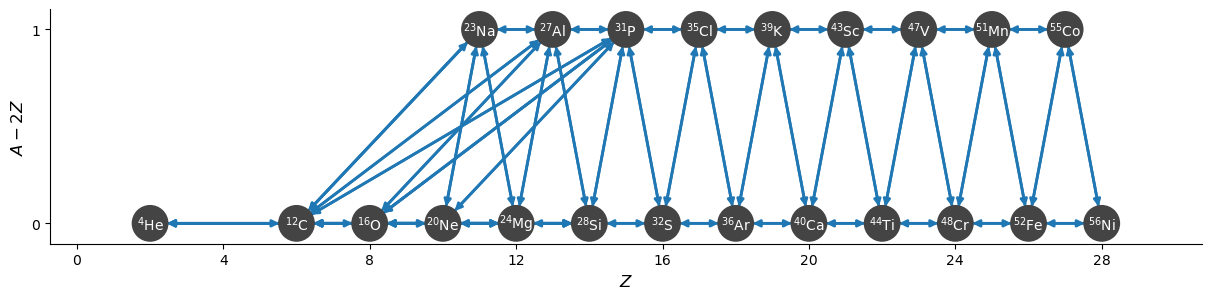

In [20]:
fig = net.plot(rotated=True, hide_xalpha=True,
               size=(1200, 300), node_size=600, node_font_size=10)

In [4]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 23
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 92

  rates explicitly connecting nuclei: 92
  hidden rates: 0

  reaclib rates: 46
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 0
  approximate rates: 0
  derived rates: 46
  modified rates: 0
  custom rates: 0


## Approximating

Now we'll approximate the C/O burning

In [6]:
from pynucastro.rates.aprox_family_rates import make_CO_approximation

In [7]:
approx_net = pyna.PythonNetwork(rates=net.get_rates())

In [8]:
new_rates, old_rate_str = make_CO_approximation(approx_net.get_rates(), "C")
rr = [net.get_rate_by_name(r) for r in old_rate_str]

approx_net.remove_rates(rr)
approx_net.add_rates(new_rates)
approx_net.remove_nuclei(["na23"])

C12 C12 Ne20 Mg24 Na23


In [9]:
new_rates, old_rate_str = make_CO_approximation(approx_net.get_rates(), "CO")
rr = [net.get_rate_by_name(r) for r in old_rate_str]

approx_net.remove_rates(rr)
approx_net.add_rates(new_rates)
approx_net.remove_nuclei(["al27"])

C12 O16 Mg24 Si28 Al27


In [10]:
new_rates, old_rate_str = make_CO_approximation(approx_net.get_rates(), "O")
rr = [net.get_rate_by_name(r) for r in old_rate_str]

approx_net.remove_rates(rr)
approx_net.add_rates(new_rates)
approx_net.remove_nuclei(["p31"])

O16 O16 Si28 S32 P31


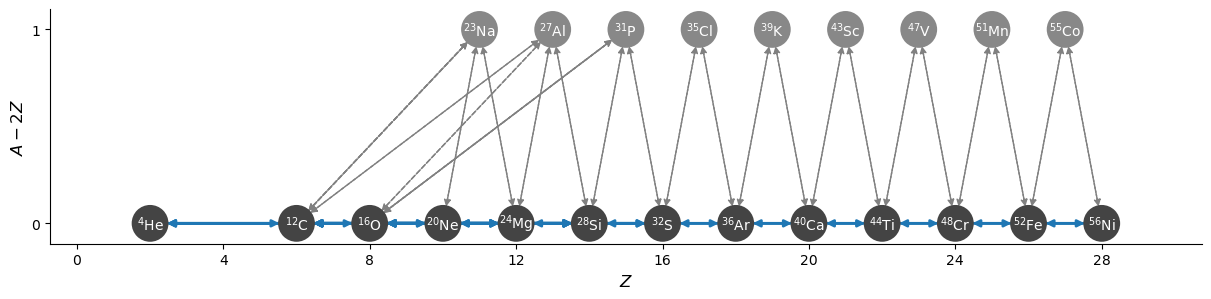

In [18]:
fig = approx_net.plot(rotated=True, hide_xalpha=True,
                      size=(1200, 300), node_size=600, node_font_size=10)

now the $(\alpha,p)(p,\gamma)$ approximation

In [12]:
approx_net.make_ap_pg_approx(intermediate_nuclei=["cl35", "k39", "sc43", "v47", "mn51", "co55"])
approx_net.remove_nuclei(["cl35", "k39", "sc43", "v47", "mn51", "co55"])

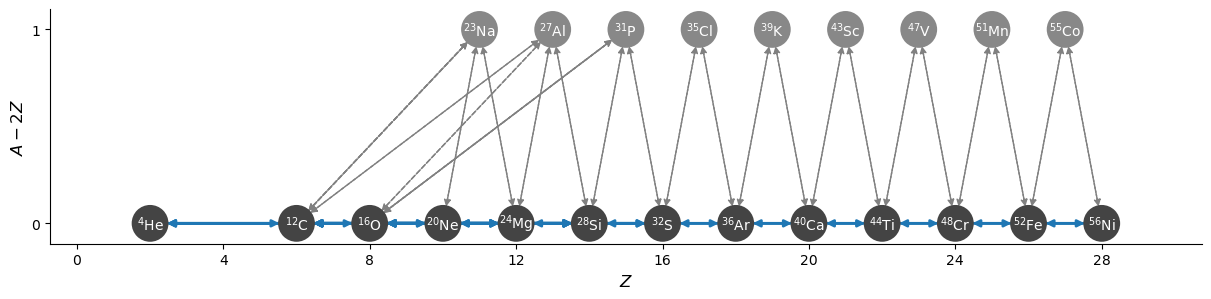

In [17]:
fig = approx_net.plot(rotated=True, hide_xalpha=True,
                      size=(1200, 300), node_size=600, node_font_size=10)